# Objective

1) make sure there are no duplicates
2) in your case, take the most prevalent classes for coronavirus then
3) take the 99.9% of sequence length. <b> use the 99.9% sequence length number we got from prev dataset </b>
   
Instead of taking the top 1% prevalence virus hosts since your data is too small for that to make sense, we are doing it by count. In the reference Jupyter notebook there should already be a function that can perform this. You can send in the column for virus host taxon id instead of name to this function and could do a minimum count of something like 20 to start. As you are working with a smaller dataset, for the sequence length in 99.9% I would maybe base that on the entire UniRef50 data (blessy correct me if I’m wrong). I just want to make sure we are on the same page and that your data gets the correct preprocessing

In [3]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

# Functions

In [4]:

def column_stats_new(df, id_column, name_column, tax_id_column, n=None):
    if n is None:
        n = df.shape[0]
    count_column = name_column + "_count"
    count_df = df[[name_column, tax_id_column, id_column]].groupby([name_column, tax_id_column]).count().reset_index()
    count_df.columns=[name_column, tax_id_column, count_column]
    count_df[name_column + "_percent"] = count_df[count_column].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[name_column].unique())}")
    return count_df

def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index()
    count_df.columns=[column_name, count_column_name]
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    print(f"{count_df}")
    return count_df
    
def filter_with_threshold(df, column_name, threshold):
    print(f"Size of df = {df.shape}")
    n = df.shape[0]
    count_df = column_stats(df, column_name, n=n)
    percent_column_name = column_name + "_percent"
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}") 
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [5]:
def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"])
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

# File outputted from step 9

In [6]:
file = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus_host_vertebrates_w_seq.csv")
df = pd.read_csv(file)
df["seq_len"] = df["seq"].apply(lambda x: len(x))
df = df[~df.duplicated()] #Removing duplicates
output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/uniref50_validhosts.csv")
df.to_csv(output, index=False) #230 rows
df

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species,MQRALLIMTLLCLVRAKFADDLLDLLTFPGAHRFLHKLTSNSSSLY...,580
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...,253
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species,VTXGRNCLFNKAIPAHMQDGXNXVXGITWDNDRVTVFXDKIYHFYX...,491
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...,272
4,UniRef50_A0A5Q0TVS7,11118,NaN,QGA70693.1,['Erinaceus amurensis'],erinaceus amurensis,Coronaviridae,family,757341,species,MQCKRLLFFIACNLLSISLAKPYIPEHCGNFEGALLQACLQSALTD...,103
...,...,...,...,...,...,...,...,...,...,...,...,...
532,UniRef50_A0A4D6FTP0,2569586,NaN,QCB65094.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species,MDETCSPEILLLKKQAQQSRLRLISLQPFIVKGPGGSWVYKFDDHE...,69
533,UniRef50_A0A4D6FTX3,2569586,NaN,QCB65098.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species,MSDDSSCCIHNPCLSEWCVYCNPPDEDVPLHVLSFIINSQQELLEL...,53
534,UniRef50_A0A4D6FWC5,694013,NaN,QCB65106.1,['Branta canadensis'],branta canadensis,Gammacoronavirus,genus,8853,species,MDMAQVVKTPLEASVKTMEARLGCGSSECEWNWSKHTNRLPLCLFS...,97
535,UniRef50_A0A4P2VDR0,136187,NaN,BBD43534.1,['Donkey'],donkey,Equine coronavirus,no rank,9793,species,AWSVDSCLQDGRCNIFSNLILNGVNSGATCSTDLQRSNTEIVVGVC...,217


In [7]:
bat = df[df["virus_host_tax_id"] == 0]
bat

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len


In [8]:
my_df = column_stats_new(df, "uniref50_id", "virus_host_name", "virus_host_tax_id")
my_df 

Number of unique values = 122


,virus_host_name,virus_host_tax_id,virus_host_name_count,virus_host_name_percent
0,anas platyrhynchos,8839,2,0.377358
1,anas superciliosa,45632,7,1.320755
2,anser cygnoides,8845,1,0.188679
3,apodemus agrarius,39030,3,0.566038
4,apodemus chevrieri,129246,1,0.188679
...,...,...,...,...
118,tylonycteris robustula,526822,3,0.566038
119,vespertilio murinus,59485,1,0.188679
120,vespertilio sinensis,105273,2,0.377358
121,vicugna pacos,30538,2,0.377358


<b> Mapping all similar/equivalent names to one value </b>

In [9]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata.csv")
clean = pd.read_csv(file_path)
clean

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
4,UniRef50_A0A5Q0TVS7,11118,NaN,QGA70693.1,['Erinaceus amurensis'],erinaceus amurensis,Coronaviridae,family,757341,species
...,...,...,...,...,...,...,...,...,...,...
669,UniRef50_A0A4D6FTP0,2569586,NaN,QCB65094.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species
670,UniRef50_A0A4D6FTX3,2569586,NaN,QCB65098.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species
671,UniRef50_A0A4D6FWC5,694013,NaN,QCB65106.1,['Branta canadensis'],branta canadensis,Gammacoronavirus,genus,8853,species
672,UniRef50_A0A4P2VDR0,136187,NaN,BBD43534.1,['Donkey'],donkey,Equine coronavirus,no rank,9793,species


In [10]:
# mapping_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_s_uniref50_embl_hosts_pruned_metadata_manual_mapping.csv")
# mapping_df = pd.read_csv(mapping_file_path, encoding = "unicode_escape")
# mapping_df["mapped_virus_host_name"] = mapping_df["mapped_virus_host_name"].apply(lambda x: unicodedata.normalize("NFKD", x))
# print(mapping_df.shape)
# mapping_df.head()

# name_name_map = mapping_df.set_index("virus_host_name")["mapped_virus_host_name"].to_dict()
# name_name_map

# name_id_map = mapping_df.set_index("virus_host_name")["mapped_virus_host_tax_id"].to_dict()
# name_id_map

# name_keys = list(name_name_map.keys())
# name_keys

# df["virus_host_taxon_rank"] = df.apply(lambda x: "species" if x["virus_host_name"] in name_keys else x["virus_host_taxon_rank"], axis=1)
# df["virus_host_tax_id"] = df.apply(lambda x: name_id_map[x["virus_host_name"]] if x["virus_host_name"] in name_keys else x["virus_host_tax_id"], axis=1)
# df[df["virus_host_name"].isin(name_keys)][["virus_host_name", "virus_host_tax_id", "virus_host_taxon_rank"]]

# Update virus_host_name

In [11]:
# df["virus_host_name"] = df.apply(lambda x: name_name_map[x["virus_host_name"]] if x["virus_host_name"] in name_keys else x["virus_host_name"], axis=1)
# df[["embl_host_name", "virus_host_name", "virus_host_tax_id", "virus_host_taxon_rank"]]

In [12]:
print(df.shape)
df.head()

(530, 12)


,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species,MQRALLIMTLLCLVRAKFADDLLDLLTFPGAHRFLHKLTSNSSSLY...,580
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...,253
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species,VTXGRNCLFNKAIPAHMQDGXNXVXGITWDNDRVTVFXDKIYHFYX...,491
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...,272
4,UniRef50_A0A5Q0TVS7,11118,NaN,QGA70693.1,['Erinaceus amurensis'],erinaceus amurensis,Coronaviridae,family,757341,species,MQCKRLLFFIACNLLSISLAKPYIPEHCGNFEGALLQACLQSALTD...,103


In [13]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_s_uniref90_embl_hosts_pruned_metadata_corrected.csv")
df.to_csv(file_path, index=False)
#"/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_s_uniref50_embl_hosts_pruned_metadata_manual_mapping.csv"

<b> Filtering by minimum count since dataset too small for prevalence </b>

 In the reference Jupyter notebook there should already be a function that can perform this. You can send in the column for virus host taxon id instead of name to this function and could do a minimum count of something like 20 to start.

In [14]:
print(df.shape)
host_tax_counts = column_stats(df, "virus_host_tax_id")
host_tax_counts

(530, 12)
Number of unique values = 114
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      125                  23.584906
1                 9031                       61                  11.509434
2                 9685                       36                   6.792453
3                 9823                       19                   3.584906
4                 9612                       17                   3.207547
..                 ...                      ...                        ...
109             225400                        1                   0.188679
110             229078                        1                   0.188679
111              94961                        1                   0.188679
112               9925                        1                   0.188679
113               9793                        1                   0.188679

[114 rows x 3 columns]


,virus_host_tax_id,virus_host_tax_id_count,virus_host_tax_id_percent
0,9606,125,23.584906
1,9031,61,11.509434
2,9685,36,6.792453
3,9823,19,3.584906
4,9612,17,3.207547
...,...,...,...
109,225400,1,0.188679
110,229078,1,0.188679
111,94961,1,0.188679
112,9925,1,0.188679


In [15]:
new = df[df["virus_host_tax_id"] == 9986]
new

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
137,UniRef50_A0A1C9EIW8,1898672,NaN,AOO19775.1,['Oryctolagus cuniculus; breed: New Zealand ra...,oryctolagus cuniculus,Rabbit coronavirus,species,9986,species,NVPYVYNGSAQATALCHSGSLVLNNFAYIAREANLGDYYYKVEADF...,158
313,UniRef50_H9AA29,1160968,NaN,AFE48790.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MAVAYADMPNHFINFSLTHFEGFVLNYKGLQFQILDVGVDCKI,43
315,UniRef50_H9AA30,1160968,NaN,AFE48791.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MLDIQPEDYISVDVAIQEVIDDMHWCDGFQIKFENPHILGRCIVLD...,63
317,UniRef50_H9AA32,1160968,NaN,AFE48793.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MIMGYCCLEVVRNELEEGHLPENACFKLSYHYENNSWFFRHVYRKS...,71
320,UniRef50_H9AA40,1160968,NaN,AFE48801.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MAVAYADMPNHFINFPLTHFEGFVLNYKGLQFQILDIGVDCKIQTA...,115
323,UniRef50_H9AA41,1160968,NaN,AFE48792.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHFNYKITINPSSPARLEIVKLGAEKKDGFYETIVSHWVGIT,42
326,UniRef50_H9AA52,1160968,NaN,AFE48814.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MIMGYWFLEVVRNELEEGHLPENDAWFKLSYHYENNSWFFRHVYRK...,58
329,UniRef50_H9AA53,1160968,NaN,AFE48815.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MMLGLSYRTIMKTILGSFGMSIGKVFISVRLVKIDCNCLRFYESSFEED,49
332,UniRef50_H9AA62,1160968,NaN,AFE48824.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHWGDGFQTKFENSHILGRCIVLDVKGVEELHDDLVNYIRD,41
335,UniRef50_H9AA63,1160968,NaN,AFE48825.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHCNYKITINPSSPARLEIVKLGAEKKDGFYETIVSHWVGIRYEHN...,107


Top 5 virus host tax ids:

0	9606 homo sapiens (humans) : count = 125

1	9031 gallus gallus (chicken) : count = 61

2   9685 felis catus (cat) : count = 36

3	9823 sus scrofa (pig, swine) : count = 19

4	9612 canis lupus (wolf) : count = 17

no occurrences of bats?

oryctolagus cuniculus (european rabbit) has occurrence of 10, 9986

In [16]:
count = df["virus_host_tax_id"].value_counts().reset_index()
print(count)

     virus_host_tax_id  count
0                 9606    125
1                 9031     61
2                 9685     36
3                 9823     19
4                 9612     17
..                 ...    ...
109             225400      1
110             229078      1
111              94961      1
112               9925      1
113               9793      1

[114 rows x 2 columns]


In [17]:
host_tax_ids = [9606, 9031, 9685, 9823, 9612, 9986]
host_tax = {
    9606: "Homo Sapiens",
    9031: "Gallus Gallus",
    9685: "Felis Catus",
    9823: "Sus Scrofa",
    9612: "Canis Lupus",
    9986: "Oryctolagus Cuniculus"
}

In [18]:
top = count[count["count"] >= 10]
top.loc[:, "host_name"] = top["virus_host_tax_id"].map(host_tax)
top

/localscratch/ipykernel_813540/1496724875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top.loc[:, "host_name"] = top["virus_host_tax_id"].map(host_tax)


,virus_host_tax_id,count,host_name
0,9606,125,Homo Sapiens
1,9031,61,Gallus Gallus
2,9685,36,Felis Catus
3,9823,19,Sus Scrofa
4,9612,17,Canis Lupus
5,9986,10,Oryctolagus Cuniculus


<b> 99.9% of the sequence lengths </b>

take the 99.9% of sequence length. use the 2400 sequence length number we got from prev dataset

Instead of taking the top 1% prevalence virus hosts since your data is too small for that to make sense, we are doing it by count. In the reference Jupyter notebook there should already be a function that can perform this. You can send in the column for virus host taxon id instead of name to this function and could do a minimum count of something like 20 to start. As you are working with a smaller dataset, for the sequence length in 99.9% I would maybe base that on the entire UniRef50 data (blessy correct me if I’m wrong). I just want to make sure we are on the same page and that your data gets the correct preprocessing

min seq len = 13
max seq len = 7078


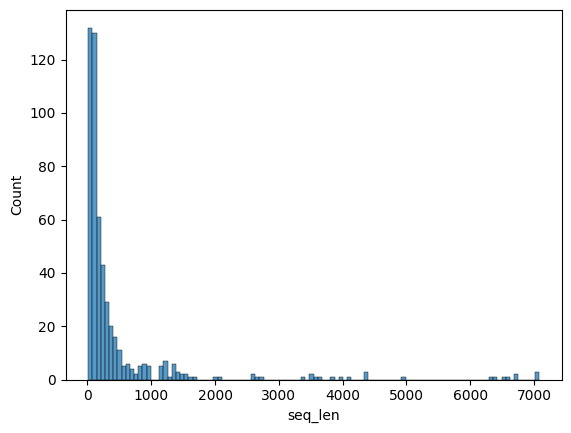

      start      end  count  percentage
0     13.00   601.75    447   84.339623
1    601.75  1190.50     33    6.226415
2   1190.50  1779.25     23    4.339623
3   1779.25  2368.00      2    0.377358
4   2368.00  2956.75      4    0.754717
5   2956.75  3545.50      3    0.566038
6   3545.50  4134.25      5    0.943396
7   4134.25  4723.00      3    0.566038
8   4723.00  5311.75      1    0.188679
9   5311.75  5900.50      0    0.000000
10  5900.50  6489.25      2    0.377358
11  6489.25  7078.00      7    1.320755


In [19]:
print_seq_len_histogram(df, 12)

<b> Sequence Length findings before filtering by minimum count </b>

Number of unique values = 111
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      122                  23.968566
1                 9031                       60                  11.787819
2                 9685                       35                   6.876228
3                 9823                       18                   3.536346
4                 9612                       17                   3.339882
..                 ...                      ...                        ...
106             225400                        1                   0.196464
107             229078                        1                   0.196464
108              94961                        1                   0.196464
109               9925                        1                   0.196464
110               9793                        1                   0.196464

[111 rows x 3 columns]
(509, 12)
min seq len = 13
max seq len = 2717


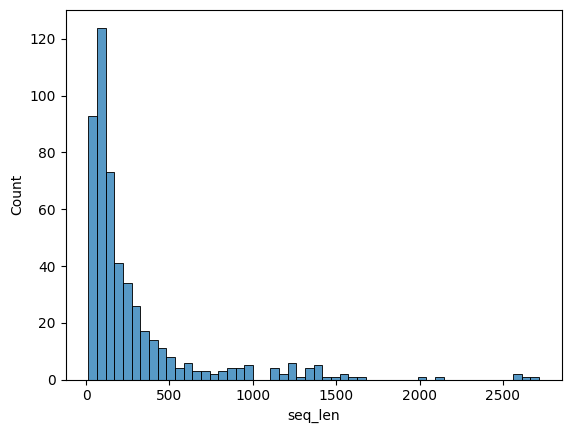

    start     end  count  percentage
0    13.0   283.4    376   73.870334
1   283.4   553.8     66   12.966601
2   553.8   824.2     19    3.732809
3   824.2  1094.6     14    2.750491
4  1094.6  1365.0     17    3.339882
5  1365.0  1635.4     10    1.964637
6  1635.4  1905.8      1    0.196464
7  1905.8  2176.2      2    0.392927
8  2176.2  2446.6      0    0.000000
9  2446.6  2717.0      4    0.785855


,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
369,UniRef50_A0AAE6M5H8,2587487,NaN,QEG08237.1,['Oncorhynchus tshawytscha'],oncorhynchus tshawytscha,Pacific salmon nidovirus,no rank,74940,species,MCGVFLSANGKLVARVDKSIRSVDVNITKGDGSRVSFIGTCKKSNT...,2717


In [20]:
filtered = df[df["seq_len"] <= 2988]
#using the 99.9% from original entire uniref50 dataset
column_stats(filtered, "virus_host_tax_id")
print(filtered.shape)
print_seq_len_histogram(filtered, 10)

output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_seq_len.csv")
filtered.to_csv(output_file_path, index=False)
findings = filtered[filtered["seq_len"] == 2717]
findings
#highest sequence is chinook salmon, lowest is canis lupus (wolf)

In [21]:
column_stats(filtered, "virus_host_tax_id")

Number of unique values = 111
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      122                  23.968566
1                 9031                       60                  11.787819
2                 9685                       35                   6.876228
3                 9823                       18                   3.536346
4                 9612                       17                   3.339882
..                 ...                      ...                        ...
106             225400                        1                   0.196464
107             229078                        1                   0.196464
108              94961                        1                   0.196464
109               9925                        1                   0.196464
110               9793                        1                   0.196464

[111 rows x 3 columns]


,virus_host_tax_id,virus_host_tax_id_count,virus_host_tax_id_percent
0,9606,122,23.968566
1,9031,60,11.787819
2,9685,35,6.876228
3,9823,18,3.536346
4,9612,17,3.339882
...,...,...,...
106,225400,1,0.196464
107,229078,1,0.196464
108,94961,1,0.196464
109,9925,1,0.196464


In [22]:
saved_df = column_stats(filtered, "virus_host_tax_id")
saved_df

output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/filtered_seq_df")
saved_df.to_csv(output, index=False)

Number of unique values = 111
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      122                  23.968566
1                 9031                       60                  11.787819
2                 9685                       35                   6.876228
3                 9823                       18                   3.536346
4                 9612                       17                   3.339882
..                 ...                      ...                        ...
106             225400                        1                   0.196464
107             229078                        1                   0.196464
108              94961                        1                   0.196464
109               9925                        1                   0.196464
110               9793                        1                   0.196464

[111 rows x 3 columns]


In [28]:
filtered.loc[:, "virus_host_tax_id_count"] = (
    filtered.groupby("virus_host_tax_id")["virus_host_tax_id"]
    .transform("count"))
filtered
entire = filtered[filtered["virus_host_tax_id_count"] >= 10]
#print(entire)

final = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/final_filtered_df.csv")
entire.to_csv(final, index = False)
entire

df = entire[entire["virus_host_name"] == 9986]
df

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len,virus_host_tax_id_count
137,UniRef50_A0A1C9EIW8,1898672,NaN,AOO19775.1,['Oryctolagus cuniculus; breed: New Zealand ra...,oryctolagus cuniculus,Rabbit coronavirus,species,9986,species,NVPYVYNGSAQATALCHSGSLVLNNFAYIAREANLGDYYYKVEADF...,158,10
313,UniRef50_H9AA29,1160968,NaN,AFE48790.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MAVAYADMPNHFINFSLTHFEGFVLNYKGLQFQILDVGVDCKI,43,10
315,UniRef50_H9AA30,1160968,NaN,AFE48791.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MLDIQPEDYISVDVAIQEVIDDMHWCDGFQIKFENPHILGRCIVLD...,63,10
317,UniRef50_H9AA32,1160968,NaN,AFE48793.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MIMGYCCLEVVRNELEEGHLPENACFKLSYHYENNSWFFRHVYRKS...,71,10
320,UniRef50_H9AA40,1160968,NaN,AFE48801.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MAVAYADMPNHFINFPLTHFEGFVLNYKGLQFQILDIGVDCKIQTA...,115,10
323,UniRef50_H9AA41,1160968,NaN,AFE48792.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHFNYKITINPSSPARLEIVKLGAEKKDGFYETIVSHWVGIT,42,10
326,UniRef50_H9AA52,1160968,NaN,AFE48814.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MIMGYWFLEVVRNELEEGHLPENDAWFKLSYHYENNSWFFRHVYRK...,58,10
329,UniRef50_H9AA53,1160968,NaN,AFE48815.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MMLGLSYRTIMKTILGSFGMSIGKVFISVRLVKIDCNCLRFYESSFEED,49,10
332,UniRef50_H9AA62,1160968,NaN,AFE48824.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHWGDGFQTKFENSHILGRCIVLDVKGVEELHDDLVNYIRD,41,10
335,UniRef50_H9AA63,1160968,NaN,AFE48825.1,['Oryctolagus cuniculus'],oryctolagus cuniculus,Rabbit coronavirus HKU14,species,9986,species,MHCNYKITINPSSPARLEIVKLGAEKKDGFYETIVSHWVGIRYEHN...,107,10


# Findings

<b> Filters placed: </b>

* minimum host tax id count of 10
* minimum sequence length of 2988 (based on 99.9% from entire uniref50 dataset)
* this brought the dataset down from 530 to 262

<b> the top 5 hosts </b>

* 9606	: 125	Homo Sapiens
* 9031	: 61	Gallus Gallus
* 9685	: 36	Felis Catus
* 9823	: 19	Sus Scrofa
* 9612	: 17	Canis Lupus

minimum occurrence of 10: Oryctolagus Cuniculus (european rabbit)


<b> Sequence Length after filtering by minimum count of 10 </b>

min seq len = 13
max seq len = 2582


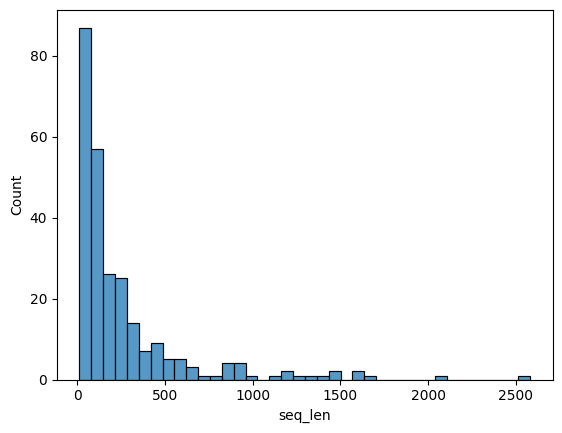

    start     end  count  percentage
0    13.0   269.9    185   70.610687
1   269.9   526.8     43   16.412214
2   526.8   783.7     12    4.580153
3   783.7  1040.6      9    3.435115
4  1040.6  1297.5      4    1.526718
5  1297.5  1554.4      4    1.526718
6  1554.4  1811.3      3    1.145038
7  1811.3  2068.2      0    0.000000
8  2068.2  2325.1      1    0.381679
9  2325.1  2582.0      1    0.381679


In [24]:
final_histogram = print_seq_len_histogram(entire, 10)
# output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/final_seq_length.csv")
# final_histogram.to_csv(output, index=False)